In [15]:
import pandas as pd

df = pd.read_csv('dataset.csv')
df

,customer_id,customer_name,product,contract_type,tenure_months,monthly_charge_gbp,payment_delays_last_6mo,num_complaints_last_6mo,open_tickets,days_since_last_contact,satisfaction_score,nps_score,last_contact_channel,payment_method,latest_support_transcript,ground_truth_risk
0,CUST-0001,Customer 1,Premium Add-on,Annual,15,121.57,0,0,0,99,4.0,7,Web Form,Credit Card,We've been customers for over four years and t...,Low
1,CUST-0002,Customer 2,Business Starter,Annual,14,131.19,6,3,4,8,1.8,4,Phone,Credit Card,I submitted a cancellation request last week a...,High
2,CUST-0003,Customer 3,Premium Add-on,Two-Year,55,70.57,0,1,0,75,3.9,9,Chat,Credit Card,Quick question about adding a second user to m...,Low
3,CUST-0004,Customer 4,Enterprise Suite,Two-Year,80,53.73,1,0,0,76,4.5,8,Phone,Invoice,Minor question about an invoice format — every...,Low
4,CUST-0005,Customer 5,Pro Plan,Monthly,19,296.75,3,3,3,6,1.6,2,Chat,Invoice,I don't know why I'm still a customer. The ser...,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,CUST-0996,Customer 996,Premium Add-on,Annual,16,135.15,2,2,1,15,3.4,5,Chat,Direct Debit,I have a question about my renewal coming up. ...,Medium
996,CUST-0997,Customer 997,Team Plan,Annual,20,54.20,1,3,0,30,2.9,7,Email,Direct Debit,I'm on the basic plan but I'm not sure it's me...,Medium
997,CUST-0998,Customer 998,Pro Plan,Two-Year,76,74.57,1,1,0,51,4.8,10,Web Form,Direct Debit,We've been customers for over four years and t...,Low
998,CUST-0999,Customer 999,Team Plan,Monthly,5,155.32,4,4,1,4,1.3,2,Web Form,Invoice,The service went down during a critical client...,High


## Data Preprocessing

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                1000 non-null   str    
 1   customer_name              1000 non-null   str    
 2   product                    1000 non-null   str    
 3   contract_type              1000 non-null   str    
 4   tenure_months              1000 non-null   int64  
 5   monthly_charge_gbp         1000 non-null   float64
 6   payment_delays_last_6mo    1000 non-null   int64  
 7   num_complaints_last_6mo    1000 non-null   int64  
 8   open_tickets               1000 non-null   int64  
 9   days_since_last_contact    1000 non-null   int64  
 10  satisfaction_score         1000 non-null   float64
 11  nps_score                  1000 non-null   int64  
 12  last_contact_channel       1000 non-null   str    
 13  payment_method             1000 non-null   str    
 14  late

### Check for null values

In [5]:
df.isna().sum()

customer_id                  0
customer_name                0
product                      0
contract_type                0
tenure_months                0
monthly_charge_gbp           0
payment_delays_last_6mo      0
num_complaints_last_6mo      0
open_tickets                 0
days_since_last_contact      0
satisfaction_score           0
nps_score                    0
last_contact_channel         0
payment_method               0
latest_support_transcript    0
ground_truth_risk            0
dtype: int64

### Correlation Matrix


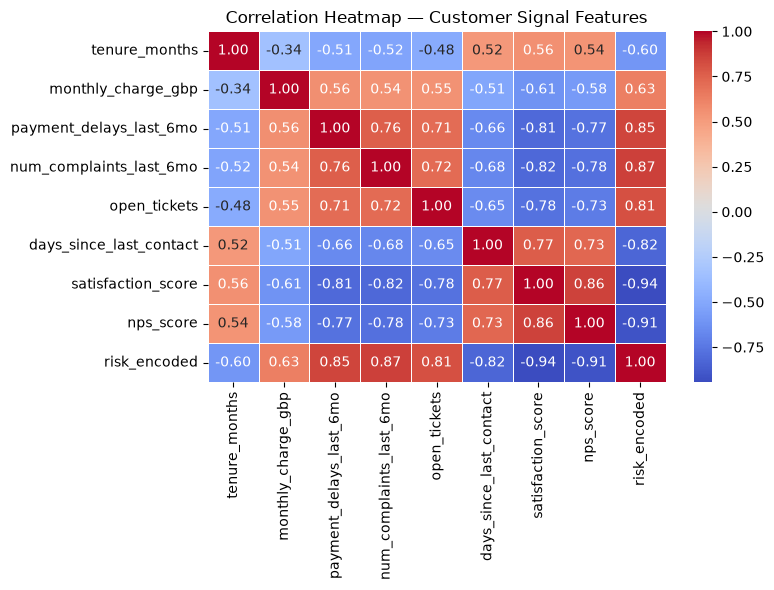

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    "tenure_months",
    "monthly_charge_gbp",
    "payment_delays_last_6mo",
    "num_complaints_last_6mo",
    "open_tickets",
    "days_since_last_contact",
    "satisfaction_score",
    "nps_score"
]

# Encode target as numeric so it appears in the matrix
risk_map = {"Low": 0, "Medium": 1, "High": 2}
df["risk_encoded"] = df["ground_truth_risk"].map(risk_map)

matrix = df[numerical_cols + ["risk_encoded"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — Customer Signal Features")
plt.tight_layout()
plt.show()

### Turn categorical values into numerical with one-hot encoding

In [ ]:
risk_map = {"Monthly": 0, "Annual": 1, "Two-Year": 2}
df["contract_type_encoded"] = df["contract_type"].map(risk_map)


categorical_cols = ["payment_method", "last_contact_channel", "product"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=False,  dtype='int')

In [17]:
df

,customer_id,customer_name,contract_type,tenure_months,monthly_charge_gbp,payment_delays_last_6mo,num_complaints_last_6mo,open_tickets,days_since_last_contact,satisfaction_score,...,payment_method_Invoice,last_contact_channel_Chat,last_contact_channel_Email,last_contact_channel_Phone,last_contact_channel_Web Form,product_Business Starter,product_Enterprise Suite,product_Premium Add-on,product_Pro Plan,product_Team Plan
0,CUST-0001,Customer 1,Annual,15,121.57,0,0,0,99,4.0,...,0,0,0,0,1,0,0,1,0,0
1,CUST-0002,Customer 2,Annual,14,131.19,6,3,4,8,1.8,...,0,0,0,1,0,1,0,0,0,0
2,CUST-0003,Customer 3,Two-Year,55,70.57,0,1,0,75,3.9,...,0,1,0,0,0,0,0,1,0,0
3,CUST-0004,Customer 4,Two-Year,80,53.73,1,0,0,76,4.5,...,1,0,0,1,0,0,1,0,0,0
4,CUST-0005,Customer 5,Monthly,19,296.75,3,3,3,6,1.6,...,1,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,CUST-0996,Customer 996,Annual,16,135.15,2,2,1,15,3.4,...,0,1,0,0,0,0,0,1,0,0
996,CUST-0997,Customer 997,Annual,20,54.20,1,3,0,30,2.9,...,0,0,1,0,0,0,0,0,0,1
997,CUST-0998,Customer 998,Two-Year,76,74.57,1,1,0,51,4.8,...,0,0,0,0,1,0,0,0,1,0
998,CUST-0999,Customer 999,Monthly,5,155.32,4,4,1,4,1.3,...,1,0,0,0,1,0,0,0,0,1


In [18]:
df.columns


Index(['customer_id', 'customer_name', 'contract_type', 'tenure_months',
       'monthly_charge_gbp', 'payment_delays_last_6mo',
       'num_complaints_last_6mo', 'open_tickets', 'days_since_last_contact',
       'satisfaction_score', 'nps_score', 'latest_support_transcript',
       'ground_truth_risk', 'risk_encoded', 'contract_type_encoded',
       'payment_method_Credit Card', 'payment_method_Direct Debit',
       'payment_method_Invoice', 'last_contact_channel_Chat',
       'last_contact_channel_Email', 'last_contact_channel_Phone',
       'last_contact_channel_Web Form', 'product_Business Starter',
       'product_Enterprise Suite', 'product_Premium Add-on',
       'product_Pro Plan', 'product_Team Plan'],
      dtype='str')

### Dataset splitting

In [19]:
from sklearn.model_selection import train_test_split

drop_cols = ["customer_id", "customer_name", "latest_support_transcript", "ground_truth_risk", "risk_encoded"]
X = df.drop(columns=drop_cols)
y = df['risk_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=4,
                           n_informative=2, n_redundant=0,
                           random_state=0, shuffle=False)
clf = RandomForestClassifier(max_depth=2, random_state=0, class_weight='balanced')
clf.fit(X, y)